## Neuroinformatics Project 2025

##### Melissa Timmermeister
##### Matriculation number: 1005348

### Import necessary librarys and load the provided datasets:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load the data
x = np.load('x.npy')
y = np.load('y.npy')

### STEP 1: Visualize the data

##### Plotting dataset "x.npy"

This dataset contains neural firing activity from multiple neurons in response to different stimuli. It has a shape of (800, 1000, 501), where each sample represents an experiment with 1000 neurons recorded over 501 time steps. In total there are 800 data samples. 

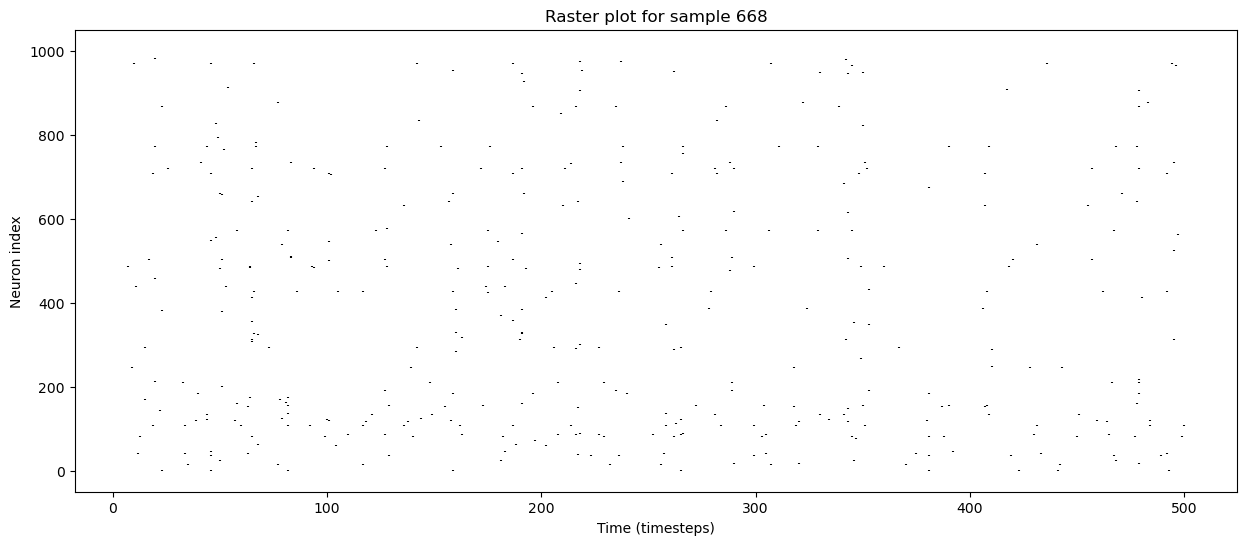

In [3]:
# Choose a random sample from the dataset
sample_idx = np.random.randint(0, x.shape[0])
sample = x[sample_idx]

# Plot raster for neurons that fired
plt.figure(figsize=(15, 6))
for neuron_idx, neuron_activity in enumerate(sample):
    spike_times = np.where(neuron_activity > 0)[0]  # find time points where neuron fired
    plt.vlines(spike_times, neuron_idx + 0.5, neuron_idx + 1.5, color='black')

# Set labels and title for the plot
plt.xlabel('Time (timesteps)')
plt.ylabel('Neuron index')
plt.title(f'Raster plot for sample {sample_idx}')
plt.show()

The raster plot visualizes the firing activity of all neurons during a randomly selected single experiment trial. Each vertical line represents a spike, showing the time at which a particular neuron fired. The x-axis corresponds to time (timesteps), while the y-axis lists the neurons. This plot shows a snapshot of the temporal firing patterns across the neural population in response to a specific stimulus.

Spike counts per sample (first 10 samples): [471 626 611 698 669 615 633 596 822 777]


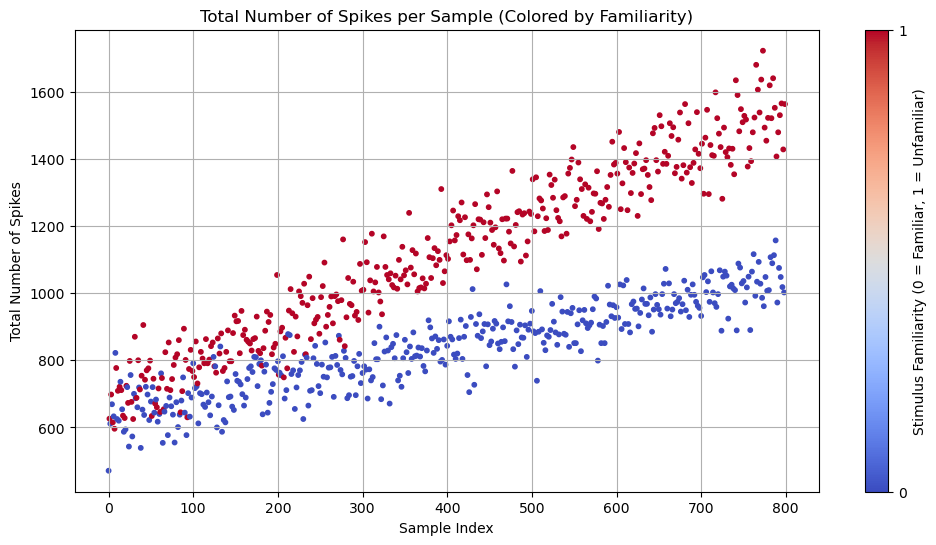

In [4]:
# Total spikes per sample
spike_counts_per_sample = (x > 0).sum(axis=(1, 2))

print(f"Spike counts per sample (first 10 samples): {spike_counts_per_sample[:10]}")

# Create a scatter plot
plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    x=np.arange(len(spike_counts_per_sample)),  # sample indices
    y=spike_counts_per_sample,
    c=y,  # color based on label
    cmap='coolwarm',
    s=10,
)

# Set labels and title for the plot
plt.xlabel('Sample Index')
plt.ylabel('Total Number of Spikes')
plt.title('Total Number of Spikes per Sample (Colored by Familiarity)')
plt.grid(True)

# Add color bar
cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.set_label('Stimulus Familiarity (0 = Familiar, 1 = Unfamiliar)')

plt.show()

The plot shows the total number of spikes recorded across all neurons and time points for each of the 800 experimental samples. Each data point represents one experiment, with the x-axis indicating the sample index and the y-axis indicating the total spike count. The color of each point corresponds to the stimulus familiarity: blue for familiar stimuli (label 0) and red for unfamiliar stimuli (label 1). The plot reveals a clear separation between the two classes, with unfamiliar stimuli mostly producing a higher total number of spikes compared to familiar stimuli. This suggests that the overall firing activity could be a strong indicator for distinguishing between familiar and unfamiliar stimuli.

##### Plotting dataset "y.npy"

This dataset contains the labels corresponding to the stimuli presented in each experiment. It has a shape of (800,), where each entry indicates whether the stimulus was familiar (label 0) or unfamiliar (label 1) to the neurons.

This following bar plot shows that an equal number of familiar and unfamiliar stimuli were used in the 800 experiments. 

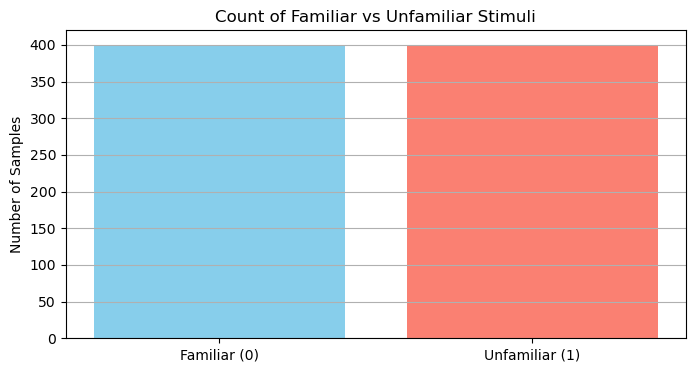

In [5]:
# Bar plot
labels, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(['Familiar (0)', 'Unfamiliar (1)'], counts, color=['skyblue', 'salmon'])
plt.title('Count of Familiar vs Unfamiliar Stimuli')
plt.ylabel('Number of Samples')
plt.grid(axis='y')
plt.show()

### STEP 2: Transform raw spikes into data suitable for classification

Based on the requirements in step 6 of the instructions for this project, I decided to compare several models for case b) different neural coding methods for transforming spike data. I applied the following neural coding methods to transform the data, plot it, create and train a model, evaluate the models, and compare them to each other: 

##### Rate Coding:

From the second plot for the dataset in x.npy in step 1, I derived that the total number of spikes in a sample could be a good feature for a binary classifier. Therefore, I decided to transform each sample in the dataset into its total number of spikes. This form of neural coding is referred to as rate coding. In rate coding, the information is encoded in the firing rate, i.e. the number of spikes over time. 

##### Firing Synchrony

Synchrony (or synchrony coding) is a type of temporal neural coding. In temporal coding, information is conveyed by the timing (pattern) of spikes, rather than just the number of spikes as in rate coding. In general, synchrony means “how similarly the neurons fire over time”, and there are different ways to quantify the synchrony of neurons in a sample. Based on the first plot for the dataset in x.npy in step 1, I chose to look at the variability of spike counts in the population. The idea behind this is that the spike count in the population fluctuates greatly when the neurons fire at the same time. A higher variance of neurons firing together in a sample means more synchrony.

In [6]:
# Rate Coding: Transform each sample into the total number of spikes

# A spike is counted whenever x > 0
total_spikes_per_sample = (x > 0).sum(axis=(1, 2))  # sum across neurons and timesteps

# The new dataset: one feature per sample
x_rate = total_spikes_per_sample.reshape(-1, 1)  # reshape to (800, 1) for scikit-learn (later necessary for logistic model)

# Print the shape of the transformed dataset and the first 10 sample values for verification
print(f"Transformed dataset shape: {x_rate.shape}")
print(f"First 10 transformed samples: {x_rate[:10].flatten()}")

Transformed dataset shape: (800, 1)
First 10 transformed samples: [471 626 611 698 669 615 633 596 822 777]


In [7]:
# Firing Synchrony: Transform each sample into the variance of co-firing neurons over time

# Set up list to calculate synchrony per sample
x_synchrony = []

for sample in x:
    # sample: shape (neurons, timesteps)
    spike_counts_per_timestep = (sample > 0).sum(axis=0)  # converts spike values to binary values and sums them across neurons for each time step
    variance_in_spike_counts = np.var(spike_counts_per_timestep)  # variance of the spike counts over time
    x_synchrony.append(variance_in_spike_counts) # store synchony value for sample in the list

# Set up the new dataset
x_synchrony = np.array(x_synchrony).reshape(-1, 1) # reshape to (800, 1) for scikit-learn (later necessary for logistic model)

# Print the shape of the transformed dataset and the first 10 sample values for verification
print(f"Transformed dataset shape: {x_synchrony.shape}")
print(f"Synchrony measure (first 10 samples): {x_synchrony[:10]}")

Transformed dataset shape: (800, 1)
Synchrony measure (first 10 samples): [[ 8.8067936 ]
 [ 9.10142191]
 [14.73822017]
 [14.47013359]
 [13.34064805]
 [11.65680615]
 [16.07030251]
 [ 7.88220764]
 [23.16433002]
 [20.74241935]]


### STEP 3: Exploratory analysis

##### Plotting the distributions of the transformed data for familiar and new classes

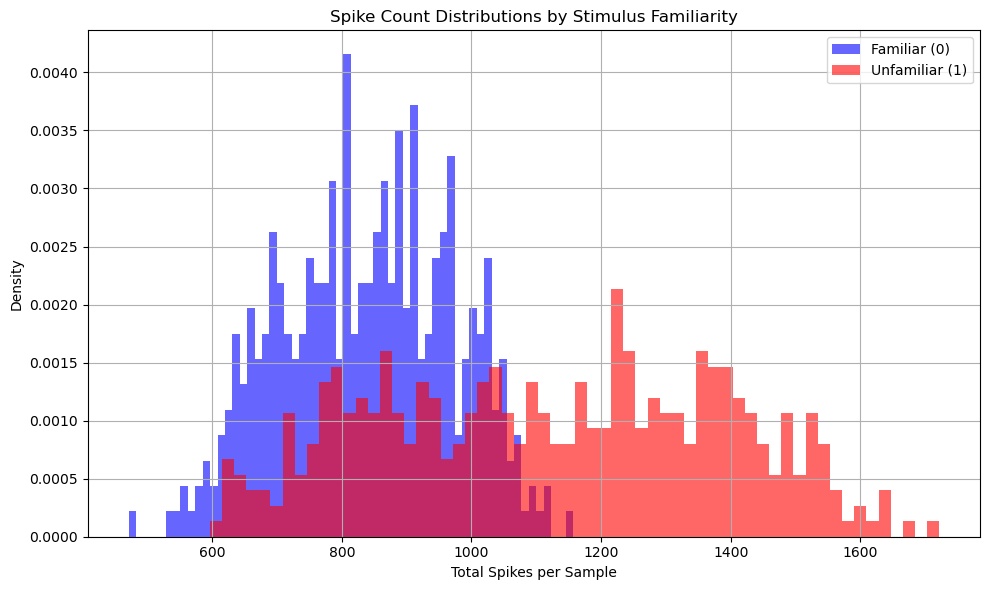

In [8]:
# Rate Coding:

# Flatten x_rate for convenience
spike_counts = x_rate.flatten()

# Separate the spike counts by class
familiar_spikes = spike_counts[y == 0]
unfamiliar_spikes = spike_counts[y == 1]

# Plot the histograms
plt.figure(figsize=(10, 6))
plt.hist(familiar_spikes, bins=60, alpha=0.6, label='Familiar (0)', color='blue', density=True)
plt.hist(unfamiliar_spikes, bins=60, alpha=0.6, label='Unfamiliar (1)', color='red', density=True)

# Set labels and title for the plot
plt.title('Spike Count Distributions by Stimulus Familiarity')
plt.xlabel('Total Spikes per Sample')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

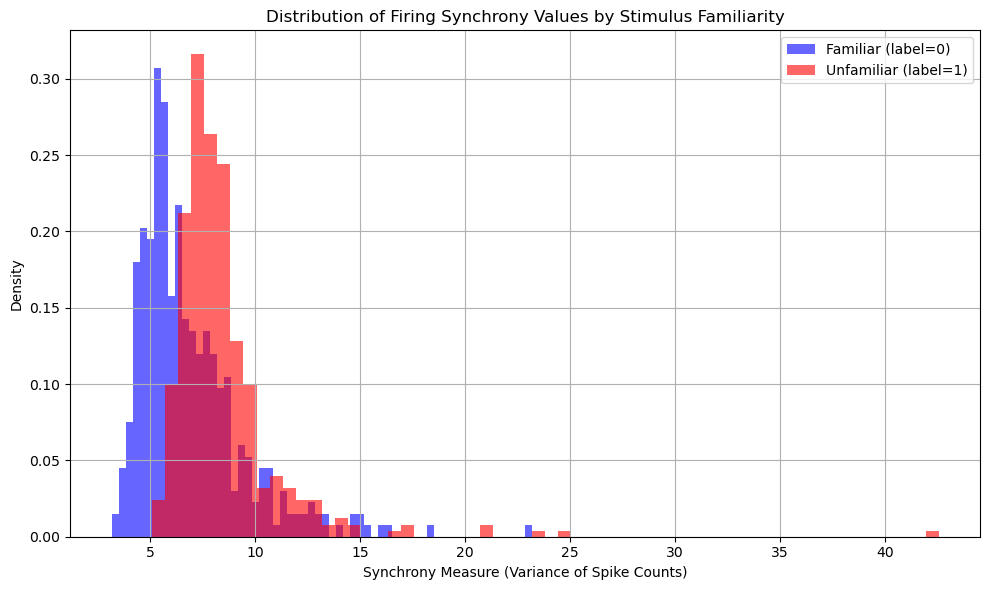

In [9]:
# Firing Synchrony:

# Flatten x_rate for convenience
synchrony_values = x_synchrony.flatten()

# Split synchrony values based on familiarity
familiar_sync = synchrony_values[y == 0]
unfamiliar_sync = synchrony_values[y == 1]

# Plot the histograms
plt.figure(figsize=(10, 6))
plt.hist(familiar_sync, bins=60, alpha=0.6, label='Familiar (label=0)', color='blue', density=True)
plt.hist(unfamiliar_sync, bins=60, alpha=0.6, label='Unfamiliar (label=1)', color='red', density=True)

# Set labels and title for the plot
plt.title('Distribution of Firing Synchrony Values by Stimulus Familiarity')
plt.xlabel('Synchrony Measure (Variance of Spike Counts)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Measureing the difference between the distributions

I chose KL divergence as a distance measure. KL divergence is useful for comparing how one distribution differs from another, which fits the goal of measuring how neural responses change with stimulus familiarity. A higher KL divergence implies greater separability between the two distributions Additionally, KL divergence is computationally inexpensive and easy to implement.

In [10]:
# Compute KL divergence between the two spike count distributions

# Create histogram values (probability distributions)
bins = np.histogram_bin_edges(spike_counts, bins=60)

# Calculate histograms for both classes
familiar_hist_rate, _ = np.histogram(familiar_spikes, bins=bins, density=True)
unfamiliar_hist_rate, _ = np.histogram(unfamiliar_spikes, bins=bins, density=True)

# Add a small value (smoothing) to avoid division by zero
epsilon = 1e-10
familiar_hist_rate += epsilon
unfamiliar_hist_rate += epsilon

# Normalize histograms to sum to 1 (so they are proper probability distributions)
familiar_hist_rate /= familiar_hist_rate.sum()
unfamiliar_hist_rate /= unfamiliar_hist_rate.sum()

# Compute and print KL divergence
kl_familiar_to_unfamiliar_rate = entropy(familiar_hist_rate, unfamiliar_hist_rate)
kl_unfamiliar_to_familiar_rate = entropy(unfamiliar_hist_rate, familiar_hist_rate)

print(f"KL Divergence (Familiar || Unfamiliar): {kl_familiar_to_unfamiliar_rate:.4f}")
print(f"KL Divergence (Unfamiliar || Familiar): {kl_unfamiliar_to_familiar_rate:.4f}")

KL Divergence (Familiar || Unfamiliar): 1.0852
KL Divergence (Unfamiliar || Familiar): 7.7191


KL(Familiar || Unfamiliar) is 1.0852, while KL(Unfamiliar || Familiar) is 7.7191. 
This asymmetry means that while familiar spike patterns are somewhat predictable relative to unfamiliar patterns, unfamiliar stimuli evoke significantly different firing behaviors compared to familiar ones.

In [11]:
# Compute KL divergence between the two synchrony value distributions

# Create histogram values (probability distributions)
bins = np.histogram_bin_edges(synchrony_values, bins=60)

# Calculate histograms for both classes
familiar_hist_sync, _ = np.histogram(familiar_sync, bins=bins, density=True)
unfamiliar_hist_sync, _ = np.histogram(unfamiliar_sync, bins=bins, density=True)

# Add a small value (smoothing) to avoid division by zero
epsilon = 1e-10
familiar_hist_sync += epsilon
unfamiliar_hist_sync += epsilon

# Normalize histograms to sum to 1 (so they are proper probability distributions)
familiar_hist_sync /= familiar_hist_sync.sum()
unfamiliar_hist_sync /= unfamiliar_hist_sync.sum()

# Compute and print KL divergence
kl_familiar_to_unfamiliar_sync = entropy(familiar_hist_sync, unfamiliar_hist_sync)
kl_unfamiliar_to_familiar_sync = entropy(unfamiliar_hist_sync, familiar_hist_sync)

print(f"KL Divergence (Familiar || Unfamiliar): {kl_familiar_to_unfamiliar_sync:.4f}")
print(f"KL Divergence (Unfamiliar || Familiar): {kl_unfamiliar_to_familiar_sync:.4f}")

KL Divergence (Familiar || Unfamiliar): 3.0190
KL Divergence (Unfamiliar || Familiar): 0.8189


KL(Familiar || Unfamiliar) is 3.0190, while KL(Unfamiliar || Familiar) is 0.8189.
This shows that familiar stimuli cause a bigger change in firing synchrony compared to unfamiliar stimuli. In contrast to spike count coding, here the familiar patterns are less predictable based on the unfamiliar ones.

### STEP 4: Model creation and training

##### Model 1:  based on firing rate data

For the first model, based on the firing rate data, I decided to use a logistic regression model. The plot with the distributions showed that the two classes (familiar vs. unfamiliar) are relatively well separated, with only one overlap between ~900 and 1100 spikes. Furthermore, the KL divergence also supports moderate separation, especially from the perspective of the unfamiliar samples. Thus, I would expect a direct relationship between spike count and stimulus familiarity and a simple linear classifier might work well based on this. In addition, logistic regression is simple, easy to implement and easy to interpret.

##### Model 2:  based on synchrony value data

For this model, I also decided to use a logistic regression model. The distribution plot and KL divergence values did not indicate the same level of separability as the for firing rate data, which speaks against using a linear classifier such as a logistic regression model. I tried it anyway to allow a direct comparison between the two data sets without model complexity being a factor. Also, linear models are good base models, i.e. a good starting point, and as mentioned earlier, easy to implement and interpret.

##### Model 3: based on synchrony value data

In [12]:
# Model 1: Logistic regression model for firing rate data

# Split the data into training and test sets
# random_state=42 makes results reproducible and startify=y ensures an even split of familiar/unfamiliar samples
x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(x_rate, y, test_size=0.2, random_state=42, stratify=y)

# Create and train the Logistic Regression model
model_1 = LogisticRegression()
model_1.fit(x_train_1, y_train_1)

LogisticRegression()

In [13]:
# Model 2: Logistic regression model for synchrony value data

# Split the data into training and test sets
# random_state=42 makes results reproducible and startify=y ensures an even split of familiar/unfamiliar samples
x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(x_synchrony, y, test_size=0.2, random_state=42, stratify=y)

# Create and train the Logistic Regression model
model_2 = LogisticRegression()
model_2.fit(x_train_2, y_train_2)

LogisticRegression()

In [ ]:
# Model 3: 

### STEP 5: Evaluation of models performance 

##### Model 1:

The overall dataset is balanced, with an equal number of familiar and unfamiliar stimuli (400 each). The split of training and testing date maintains this balance using stratification. Therefore accuracy is as a reliable and meaningful performance metric. For completeness, I have also included additional metrics such as F1 score, but these are not strictly necessary in this balanced setting. I have also included the confusion matrix to better understand the types of errors the model makes. It could show possible biases in the model's predictions even if the data set is balanced.

##### Model 2:

I used the same performance metric as for model 1 for the same reasons as stated above.

##### Model 3:

In [14]:
# Evaluation of model 1

# Make predictions for samples in the test set
y_pred_1 = model_1.predict(x_test_1)

# Evaluate the model
accuracy_1 = accuracy_score(y_test_1, y_pred_1)
conf_mat_1 = confusion_matrix(y_test_1, y_pred_1)
report_1 = classification_report(y_test_1, y_pred_1)

# Print the Evaulation
print(f"Test Accuracy: {accuracy_1:.4f}")
print("Confusion Matrix:")
print(conf_mat_1)
print("\nClassification Report:")
print(report_1)

Test Accuracy: 0.7188
Confusion Matrix:
[[61 19]
 [26 54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.76      0.73        80
           1       0.74      0.68      0.71        80

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160



The logistic regression model achieved an accuracy of 71.9% which means it correctly classifies most samples. Given the simplicity of the rate coding method and the logistic regression model, this result suggests that overall neural firing rate contains meaningful information about stimulus familiarity. Furthermore the f1-scores are similar for both classes (0.73 for familiar and 0.71 for unfamiliar). This indicates that the model does not heavily favor one class over the other. The confusion matrix also shows that the model performed reasonably well on both classes, with 61 correct predictions for familiar stimuli and 54 for unfamiliar stimuli.

In [15]:
# Evaluation of model 2

# Make predictions for samples in the test set
y_pred_2 = model_2.predict(x_test_2)

# Evaluate the model
accuracy_2 = accuracy_score(y_test_2, y_pred_2)
conf_mat_2 = confusion_matrix(y_test_2, y_pred_2)
report_2 = classification_report(y_test_2, y_pred_2)

# Print the Evaulation
print(f"Test Accuracy: {accuracy_2:.4f}")
print("Confusion Matrix:")
print(conf_mat_2)
print("\nClassification Report:")
print(report_2)

Test Accuracy: 0.6438
Confusion Matrix:
[[57 23]
 [34 46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.71      0.67        80
           1       0.67      0.57      0.62        80

    accuracy                           0.64       160
   macro avg       0.65      0.64      0.64       160
weighted avg       0.65      0.64      0.64       160



The logistic regression model achieved an accuracy of 64.4% which is lower than the accuracy for model 1. The f1-scores show a slight imbalance, with the model performing somewhat better at recognizing familiar stimuli. The confusion matrix shows that the model performed ok on both classes, with 57 correct predictions for familiar stimuli and 46 for unfamiliar stimuli. Overall the model performs above chance level but there is still a lot of room for improvement. The performance of the model could be due to the fact that this version of synchrony between neurons is not informative enough for discriminating stimulus familiarity or that logistic regression is not the ideal type of model to capture a possible relationship.

In [ ]:
# Evaluation of model 3

### STEP 6: Model comparision

##### Comparision of Model 1 and 2:

Since both are logistic regression models, I created a table displaying the evaluation metrics for both models side-by-side. This is a simple way to identify obvious performance differences.

##### Comparision of Model 2 and 3:

##### Comparision of Model 1 and 3:

In [18]:
# Model 1 vs Model 2

# Get reports as dictionaries
r1 = classification_report(y_test_1, y_pred_1, output_dict=True)
r2 = classification_report(y_test_2, y_pred_2, output_dict=True)

# Create a DataFrame with selected metrics
data = {
    'Metric': ['Accuracy',
               'Precision (0)', 'Recall (0)', 'F1-score (0)',
               'Precision (1)', 'Recall (1)', 'F1-score (1)'],
    'Model 1': [accuracy_1,
                r1['0']['precision'], r1['0']['recall'], r1['0']['f1-score'],
                r1['1']['precision'], r1['1']['recall'], r1['1']['f1-score']],
    'Model 2': [accuracy_2,
                r2['0']['precision'], r2['0']['recall'], r2['0']['f1-score'],
                r2['1']['precision'], r2['1']['recall'], r2['1']['f1-score']]
}

# Show as DataFrame
df = pd.DataFrame(data)
print(df.round(4))

          Metric  Model 1  Model 2
0       Accuracy   0.7188   0.6438
1  Precision (0)   0.7011   0.6264
2     Recall (0)   0.7625   0.7125
3   F1-score (0)   0.7305   0.6667
4  Precision (1)   0.7397   0.6667
5     Recall (1)   0.6750   0.5750
6   F1-score (1)   0.7059   0.6174


This simple table shows clearly that Model 1 outperforms Model 2 across all these metrics.

In [ ]:
# Model 2 vs Model 3